In [2]:
import pandas as pd


df = pd.read_csv('marketing_AB.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 27.5 MB


In [ ]:
import pandas as pd

# 1. Cargar el dataset (ajusta la ruta según donde guardes tu archivo)
df = pd.read_csv('marketing_AB.csv')

# Eliminar una columna de índice innecesaria si es que existe (Kaggle suele traerla como 'Unnamed: 0')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("--- 1. VERIFICACIÓN DE NULOS Y DUPLICADOS ---")
print(f"Valores nulos por columna:\n{df.isnull().sum()}\n")
print(f"Cantidad de filas completamente duplicadas: {df.duplicated().sum()}\n")

print("--- 2. CONTROL DE CONTAMINACIÓN DE GRUPOS ---")

usuarios_por_grupo = df.groupby('user id')['test group'].nunique()
usuarios_contaminados = usuarios_por_grupo[usuarios_por_grupo > 1].count()

print(f"Usuarios que aparecen en AMBOS grupos a la vez: {usuarios_contaminados}")

# Si existen usuarios contaminados, los filtramos para limpiar el experimento
if usuarios_contaminados > 0:
    usuarios_validos = usuarios_por_grupo[usuarios_por_grupo == 1].index
    df = df[df['user id'].isin(usuarios_validos)]
    print("¡Usuarios contaminados eliminados con éxito!")

--- 1. VERIFICACIÓN DE NULOS Y DUPLICADOS ---
Valores nulos por columna:
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

Cantidad de filas completamente duplicadas: 0

--- 2. CONTROL DE CONTAMINACIÓN DE GRUPOS ---
Usuarios que aparecen en AMBOS grupos a la vez: 0


In [4]:
print("--- 3. DISTRIBUCIÓN DE LOS GRUPOS ---")
print(df['test group'].value_counts())
print("\nPorcentaje por grupo:")
print(df['test group'].value_counts(normalize=True) * 100)

print("\nTasa de conversión global (línea base real):")
tasa_global = df['converted'].mean() * 100
print(f"{tasa_global:.2f}% de los usuarios totales realizaron una compra.")

--- 3. DISTRIBUCIÓN DE LOS GRUPOS ---
test group
ad     564577
psa     23524
Name: count, dtype: int64

Porcentaje por grupo:
test group
ad     96.000007
psa     3.999993
Name: proportion, dtype: float64

Tasa de conversión global (línea base real):
2.52% de los usuarios totales realizaron una compra.


C:\Users\Ronaldo\AppData\Local\Temp\ipykernel_13632\531493878.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='test group', y='total ads', palette='Set2')


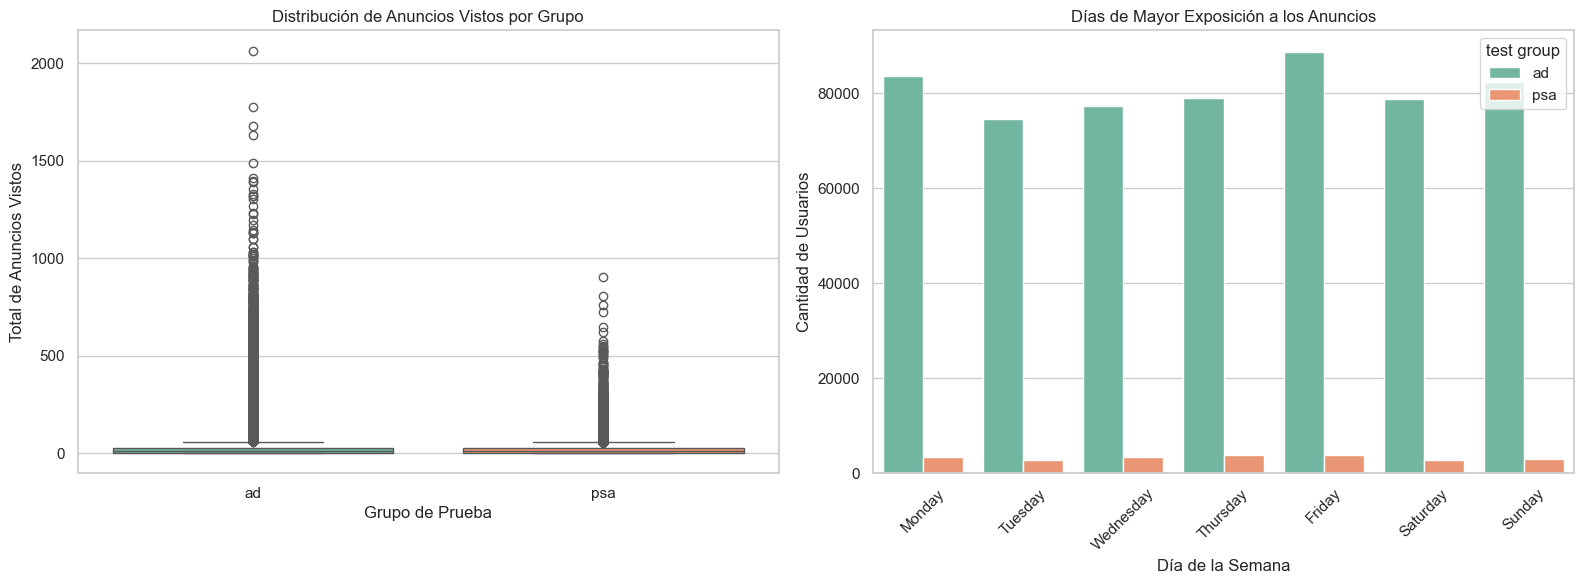

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Distribución de anuncios vistos (Detectar outliers / sesgos)
sns.boxplot(ax=axes[0], data=df, x='test group', y='total ads', palette='Set2')
axes[0].set_title('Distribución de Anuncios Vistos por Grupo')
axes[0].set_xlabel('Grupo de Prueba')
axes[0].set_ylabel('Total de Anuncios Vistos')

# Gráfico 2: Cuándo se ven más anuncios (Análisis Temporal)

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(ax=axes[1], data=df, x='most ads day', hue='test group', order=orden_dias, palette='Set2')

axes[1].set_title('Días de Mayor Exposición a los Anuncios')
axes[1].set_xlabel('Día de la Semana')
axes[1].set_ylabel('Cantidad de Usuarios')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

# 1. Cargar el dataset (ajusta la ruta según donde guardes tu archivo)
df = pd.read_csv('marketing_AB.csv')
# Calcular totales y conversiones por grupo
resumen_grupos = df.groupby('test group')['converted'].agg(['count', 'sum']).rename(columns={'count': 'Total_Usuarios', 'sum': 'Conversiones'})

# Calcular la Tasa de Conversión (CR) por grupo
resumen_grupos['Conversion_Rate'] = resumen_grupos['Conversiones'] / resumen_grupos['Total_Usuarios']
print("--- MÉTRICAS POR GRUPO ---")
print(resumen_grupos)

# Extraer los valores para los cálculos de impacto
cr_control = resumen_grupos.loc['psa', 'Conversion_Rate']
cr_treatment = resumen_grupos.loc['ad', 'Conversion_Rate']

lift_absoluto = cr_treatment - cr_control
lift_relativo = (lift_absoluto / cr_control) * 100

print(f"\nLift Absoluto: {lift_absoluto:.4f}")
print(f"Lift Relativo (Incremento): {lift_relativo:.2f}%")

--- MÉTRICAS POR GRUPO ---
            Total_Usuarios  Conversiones  Conversion_Rate
test group                                               
ad                  564577         14423         0.025547
psa                  23524           420         0.017854

Lift Absoluto: 0.0077
Lift Relativo (Incremento): 43.09%


In [7]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# 1. Preparar los arreglos con los éxitos (conversiones) y las observaciones totales
exitos = [resumen_grupos.loc['ad', 'Conversiones'], resumen_grupos.loc['psa', 'Conversiones']]
n_observaciones = [resumen_grupos.loc['ad', 'Total_Usuarios'], resumen_grupos.loc['psa', 'Total_Usuarios']]

# 2. Ejecutar el Z-Test (usando una prueba de dos colas 'two-sided' por rigor estadístico)
z_stat, p_value = proportions_ztest(exitos, nobs=n_observaciones, alternative='two-sided')

# 3. Calcular los Intervalos de Confianza al 95% para cada grupo
ci_ad_low, ci_ad_upp = proportion_confint(exitos[0], n_observaciones[0], alpha=0.05)
print(f"Intervalo de confianza 95% para el Grupo Tratamiento (ad): [{ci_ad_low:.4f}, {ci_ad_upp:.4f}]")

ci_psa_low, ci_psa_upp = proportion_confint(exitos[1], n_observaciones[1], alpha=0.05)
print(f"Intervalo de confianza 95% para el Grupo Control (psa): [{ci_psa_low:.4f}, {ci_psa_upp:.4f}]")

Intervalo de confianza 95% para el Grupo Tratamiento (ad): [0.0251, 0.0260]
Intervalo de confianza 95% para el Grupo Control (psa): [0.0162, 0.0195]


In [8]:
print("\n--- CONCLUSIÓN ESTADÍSTICA ---")
alpha = 0.05 # Nuestro nivel de significancia del 5% establecido en la Fase 1

print(f"Valor p obtenido: {p_value}")

if p_value < alpha:
    print(f"Como el valor p ({p_value}) es MENOR que alpha ({alpha}), RECHAZAMOS la hipótesis nula (H0).")
    print("Resultado: El nuevo anuncio produce un cambio estadísticamente significativo en las ventas.")
else:
    print(f"Como el valor p ({p_value}) es MAYOR o IGUAL que alpha ({alpha}), NO PODEMOS RECHAZAR la hipótesis nula (H0).")
    print("Resultado: No hay evidencia suficiente para afirmar que el nuevo anuncio sea mejor; la diferencia se debe al azar.")


--- CONCLUSIÓN ESTADÍSTICA ---
Valor p obtenido: 1.7052807161559727e-13
Como el valor p (1.7052807161559727e-13) es MENOR que alpha (0.05), RECHAZAMOS la hipótesis nula (H0).
Resultado: El nuevo anuncio produce un cambio estadísticamente significativo en las ventas.


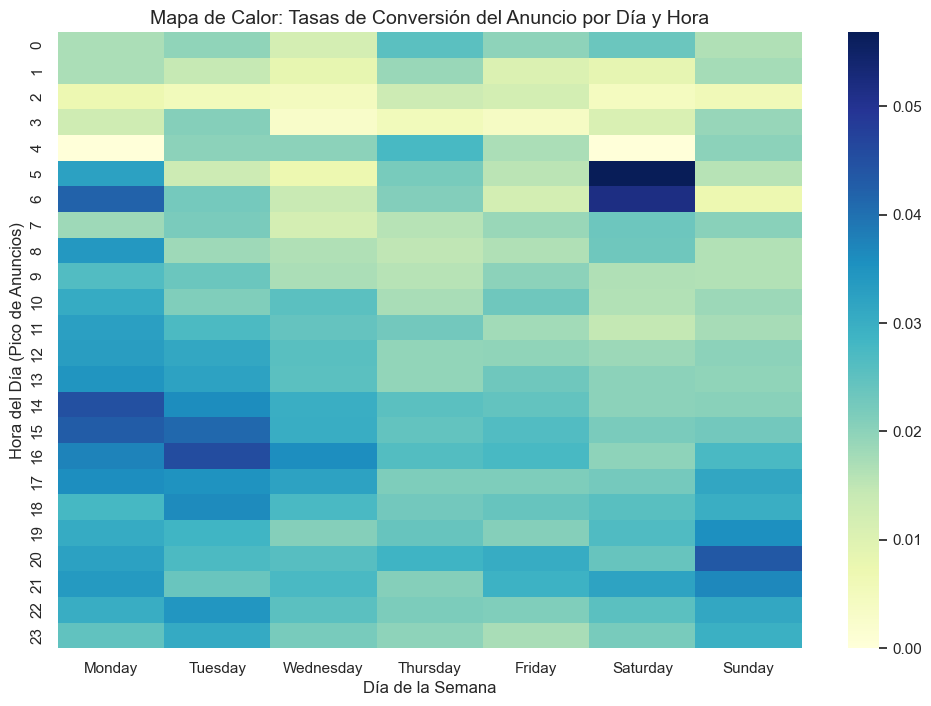

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear una tabla cruzada (Pivot Table) que calcule la tasa de conversión promedio por día y hora
# Filtramos solo para el grupo 'ad' para entender el comportamiento con el anuncio nuevo
df_ad = df[df['test group'] == 'ad']

atribucion_temporal = df_ad.pivot_table(
    values='converted', 
    index='most ads hour', 
    columns='most ads day', 
    aggfunc='mean'
)

# Reordenar las columnas para que sigan el orden lógico de los días de la semana
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
atribucion_temporal = atribucion_temporal[orden_dias]

# 2. Graficar el Mapa de Calor
plt.figure(figsize=(12, 8))
sns.heatmap(atribucion_temporal, annot=False, cmap='YlGnBu', fmt=".2%")
plt.title('Mapa de Calor: Tasas de Conversión del Anuncio por Día y Hora', fontsize=14)
plt.xlabel('Día de la Semana')
plt.ylabel('Hora del Día (Pico de Anuncios)')
plt.show()




--- ANÁLISIS DE SATURACIÓN PUBLICITARIA ---
  ads_frequency_range  Total_Usuarios  Conversion_Rate
0             1-5 ads          169962         0.002512
1            6-10 ads           79537         0.004853
2           11-20 ads          123334         0.008400
3           21-50 ads          125541         0.029154
4          51-100 ads           44149         0.116311
5            100+ ads           22054         0.171352


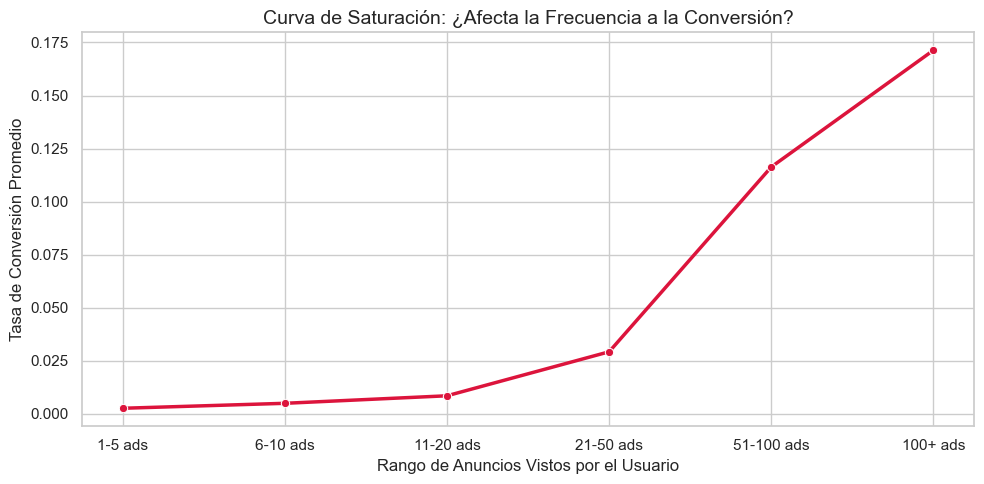

In [10]:
import numpy as np

# 1. Definir rangos lógicos para la cantidad de anuncios vistos
bins = [0, 5, 10, 20, 50, 100, np.inf]
labels = ['1-5 ads', '6-10 ads', '11-20 ads', '21-50 ads', '51-100 ads', '100+ ads']

# Crear una nueva columna con el rango correspondiente
df_ad['ads_frequency_range'] = pd.cut(df_ad['total ads'], bins=bins, labels=labels)

# 2. Calcular la tasa de conversión y contar usuarios por rango
saturacion_anuncios = df_ad.groupby('ads_frequency_range', observed=False)['converted'].agg(['count', 'mean']).reset_index()
saturacion_anuncios.rename(columns={'count': 'Total_Usuarios', 'mean': 'Conversion_Rate'}, inplace=True)

print("--- ANÁLISIS DE SATURACIÓN PUBLICITARIA ---")
print(saturacion_anuncios)

# 3. Graficar la línea de tendencia de conversión vs frecuencia
plt.figure(figsize=(10, 5))
sns.lineplot(data=saturacion_anuncios, x='ads_frequency_range', y='Conversion_Rate', marker='o', color='crimson', linewidth=2.5)
plt.title('Curva de Saturación: ¿Afecta la Frecuencia a la Conversión?', fontsize=14)
plt.xlabel('Rango de Anuncios Vistos por el Usuario')
plt.ylabel('Tasa de Conversión Promedio')
plt.tight_layout()
plt.show()

In [11]:
# Definir supuestos de negocio para la simulación de impacto
usuarios_proyectados = 1000000
ticket_promedio = 50  # en USD

# 1. Calcular conversiones estimadas con la estrategia vieja (PSA) vs la nueva (AD)
conversiones_estrategia_vieja = usuarios_proyectados * cr_control
conversiones_estrategia_nueva = usuarios_proyectados * cr_treatment

conversiones_adicionales = conversiones_estrategia_nueva - conversiones_estrategia_vieja

# 2. Calcular el impacto financiero (Ingresos brutos adicionales)
ingresos_antiguos_est = conversiones_estrategia_vieja * ticket_promedio
ingresos_nuevos_est = conversiones_estrategia_nueva * ticket_promedio
ingreso_incremental = conversiones_adicionales * ticket_promedio

print("--- 💰 IMPACTO FINANCIERO PROYECTADO (A ESCALA) ---")
print(f"Con la estrategia anterior se estimaban: {int(conversiones_estrategia_vieja):,} ventas.")
print(f"Con el nuevo anuncio se proyectan: {int(conversiones_estrategia_nueva):,} ventas.")
print(f"¡Ganancia neta de {int(conversiones_adicionales):,} conversiones extra!")
print(f"\nIngreso estimado con anuncio nuevo: ${ingresos_nuevos_est:,.2f} USD")
print(f"INCREMENTO EN VENTAS (ROI): +${ingreso_incremental:,.2f} USD mensuales.")

--- 💰 IMPACTO FINANCIERO PROYECTADO (A ESCALA) ---
Con la estrategia anterior se estimaban: 17,854 ventas.
Con el nuevo anuncio se proyectan: 25,546 ventas.
¡Ganancia neta de 7,692 conversiones extra!

Ingreso estimado con anuncio nuevo: $1,277,327.98 USD
INCREMENTO EN VENTAS (ROI): +$384,622.66 USD mensuales.


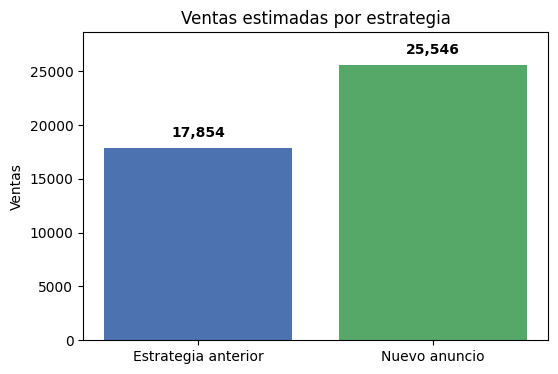

In [3]:
import matplotlib.pyplot as plt

ventas = [17854, 25546]
labels = ['Estrategia anterior', 'Nuevo anuncio']

plt.figure(figsize=(6, 4))
plt.bar(labels, ventas, color=['#4C72B0', '#55A868'])
plt.title('Ventas estimadas por estrategia')
plt.ylabel('Ventas')
for i, valor in enumerate(ventas):
    plt.text(
        i,
        valor + max(ventas) * 0.03,
        f"{valor:,}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none')
    )

plt.ylim(top=max(ventas) * 1.12)
plt.show()